In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
cmap = 'coolwarm'

In [2]:
baseline = pd.read_csv('blink_summary_all_subjects_Baseline.csv')
ride = pd.read_csv('blink_summary_all_subjects_Ride.csv')
fog=pd.read_csv('blink_summary_all_subjects_Fog.csv')


In [3]:
# Convert 'Gender' to numeric if it exists
for df in [baseline, ride, fog]:
    if 'Gender' in df.columns:
        df['Gender'] = df['Gender'].map({'M': 0, 'F': 1})

# Then select only numeric columns
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num     = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])
baseline_num.head()

,Time_min,NumBlinks,BlinkRate_perMin,MeanDur_ms,StdDur_ms,MedianDur_ms
0,12.906167,238,18.440797,168.151261,73.288821,140.0
1,1.623833,5,3.079134,160.000000,55.226805,140.0
2,6.024667,32,5.311497,238.125000,78.264955,235.0
3,14.283667,52,3.640522,160.192308,73.471093,130.0
4,6.603833,122,18.474119,141.393443,56.000525,130.0


In [4]:
baseline_num = baseline.select_dtypes(include=[np.number])
ride_num = ride.select_dtypes(include=[np.number])
fog_num = fog.select_dtypes(include=[np.number])


In [5]:
combined = pd.concat([baseline_num, ride_num, fog_num], ignore_index=True).dropna()
corr_combined = combined.corr()
corr_baseline = baseline_num.corr()
corr_ride = ride_num.corr()
corr_fog=fog_num.corr()
mask = np.triu(np.ones_like(corr_combined, dtype=bool))


In [6]:
labels = [col.replace('_', ' ') for col in corr_baseline.columns]
annot = corr_baseline.copy()
annot[mask] = np.nan

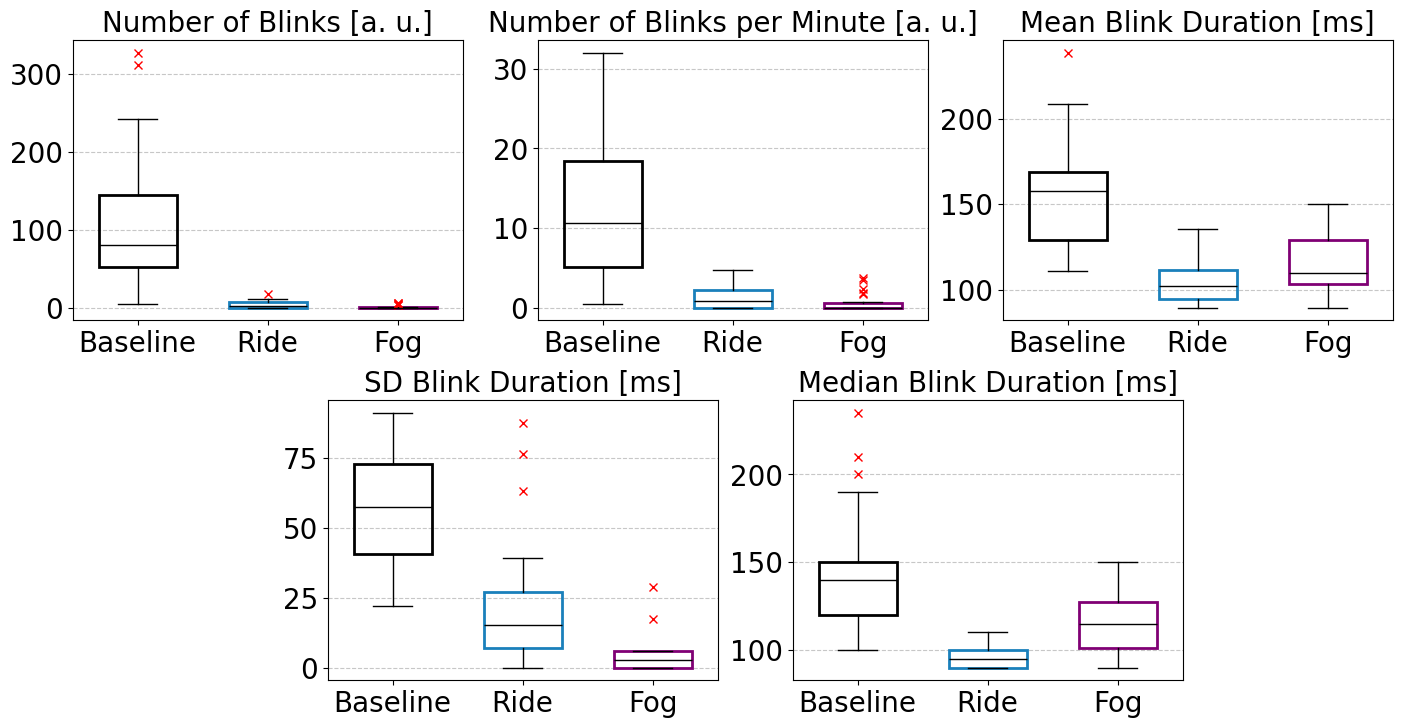

In [7]:
import matplotlib.pyplot as plt

variables = ['NumBlinks', 'BlinkRate_perMin', 'MeanDur_ms', 'StdDur_ms', 'MedianDur_ms']
custom_titles = [
    'Number of Blinks [a. u.]',
    'Number of Blinks per Minute [a. u.]',
    'Mean Blink Duration [ms]',
    'SD Blink Duration [ms]',
    'Median Blink Duration [ms]'
]

# figure size
fig = plt.figure(figsize=(15, 8))

# manual axes positions [left, bottom, width, height]
top_y = 0.55
bottom_y = 0.1
height = 0.35

# top row: 3 columns
top_positions = [0.05, 0.36, 0.67]

# bottom row: 2 columns, centered under top row
bottom_positions = [0.22, 0.53]  # adjust these to center exactly

axes = []

# create top row axes
for i, left in enumerate(top_positions):
    ax = fig.add_axes([left, top_y, 0.26, height])  # width=0.28 fits nicely
    axes.append(ax)

# create bottom row axes
for i, left in enumerate(bottom_positions):
    ax = fig.add_axes([left, bottom_y, 0.26, height])
    axes.append(ax)

# now plot the variables
for i, var in enumerate(variables):
    ax = axes[i]
    
    # dummy example data (replace with your real data)
    data = [baseline[var].dropna(), ride[var].dropna(), fog[var].dropna()]
    positions = [1, 2, 3]
    
    bplot = ax.boxplot(
        data,
        positions=positions,
        widths=0.6,
        patch_artist=True,
        showfliers=True,
        flierprops=dict(marker='x', markerfacecolor='red', markeredgecolor='red', markersize=6),
        medianprops=dict(color='black')
    )
    
    colors = ["#000000", '#1a80bb', '#800074']
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor('none')
        patch.set_edgecolor(color)
        patch.set_linewidth(2)
    
    ax.set_xticks(positions)
    ax.set_xticklabels(['Baseline', 'Ride', 'Fog'], fontsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_title(custom_titles[i], fontsize=20)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig('BlinksBoxplot.jpg', dpi=300)
plt.show()


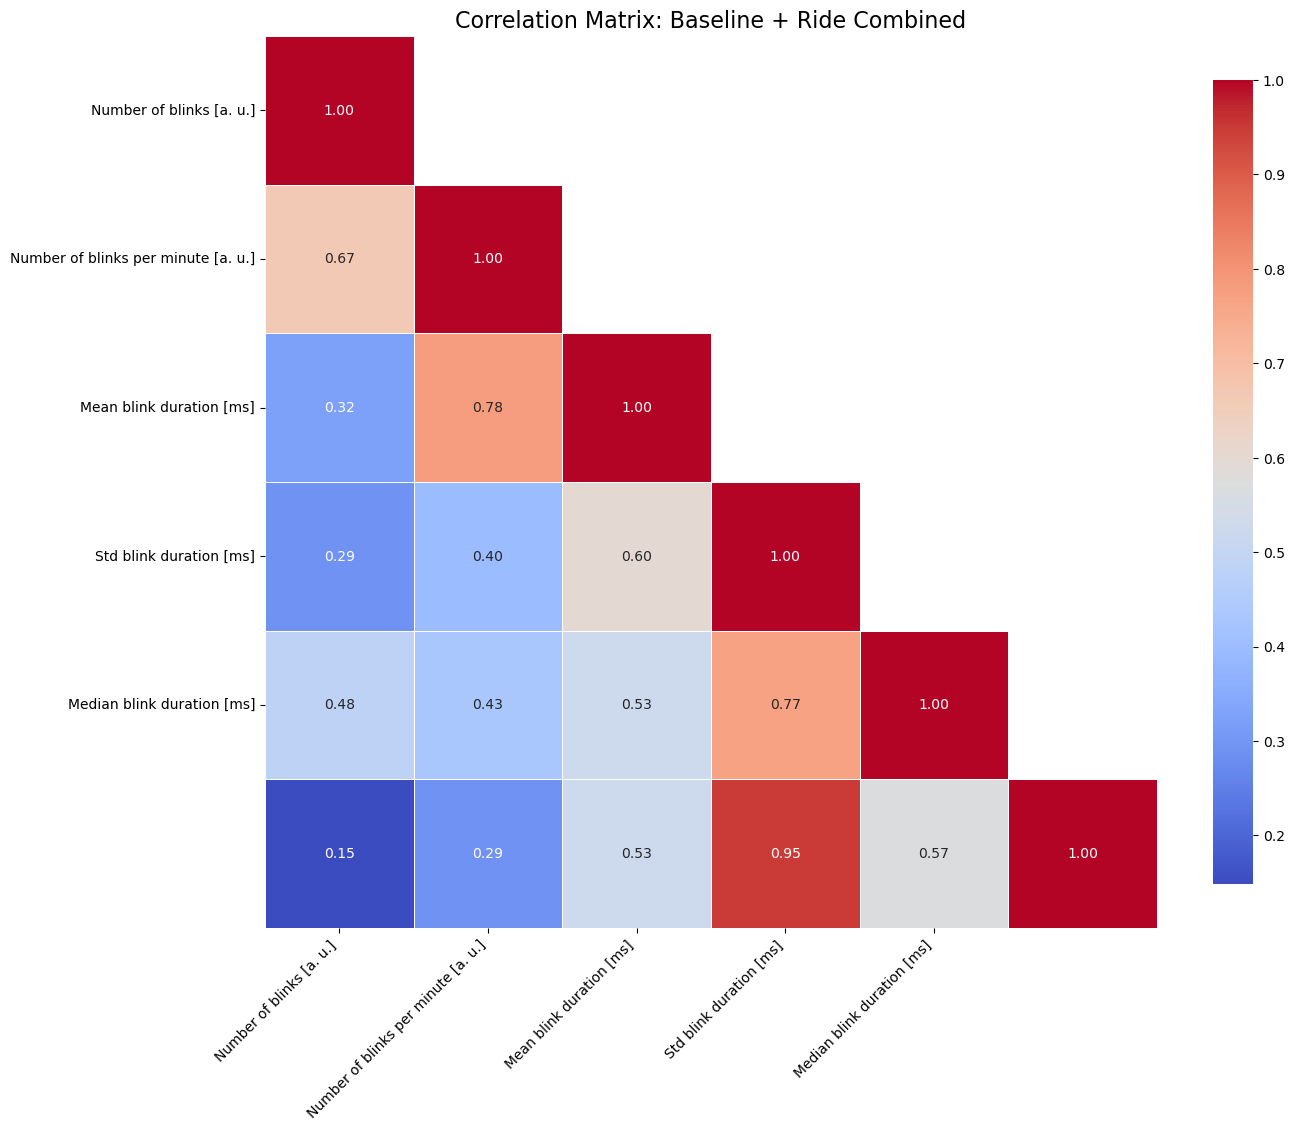

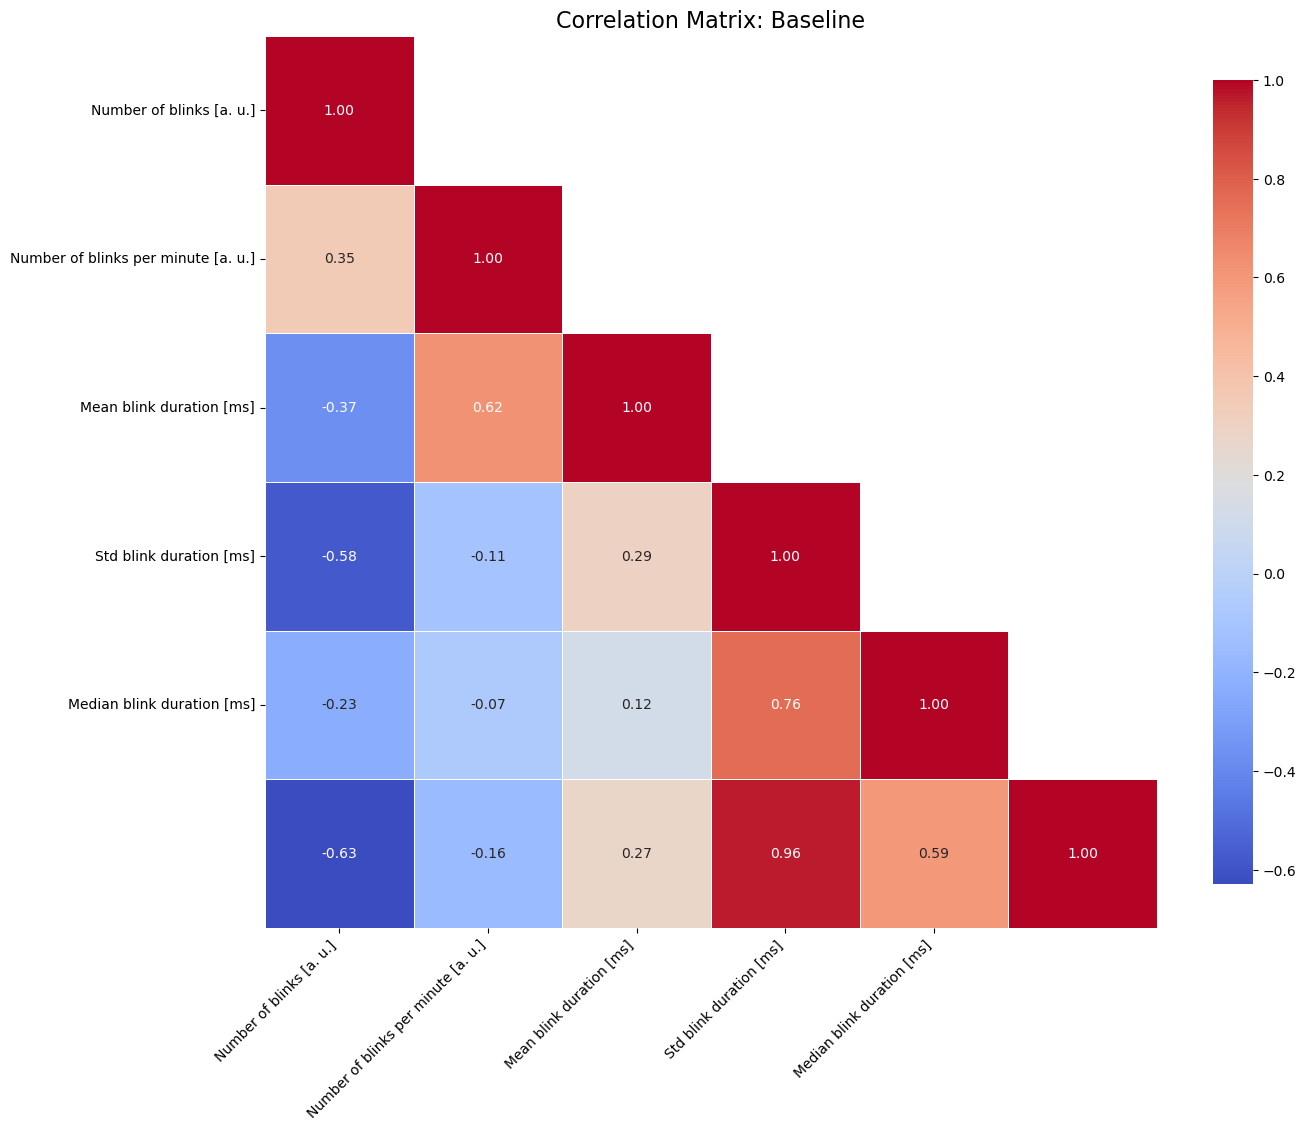

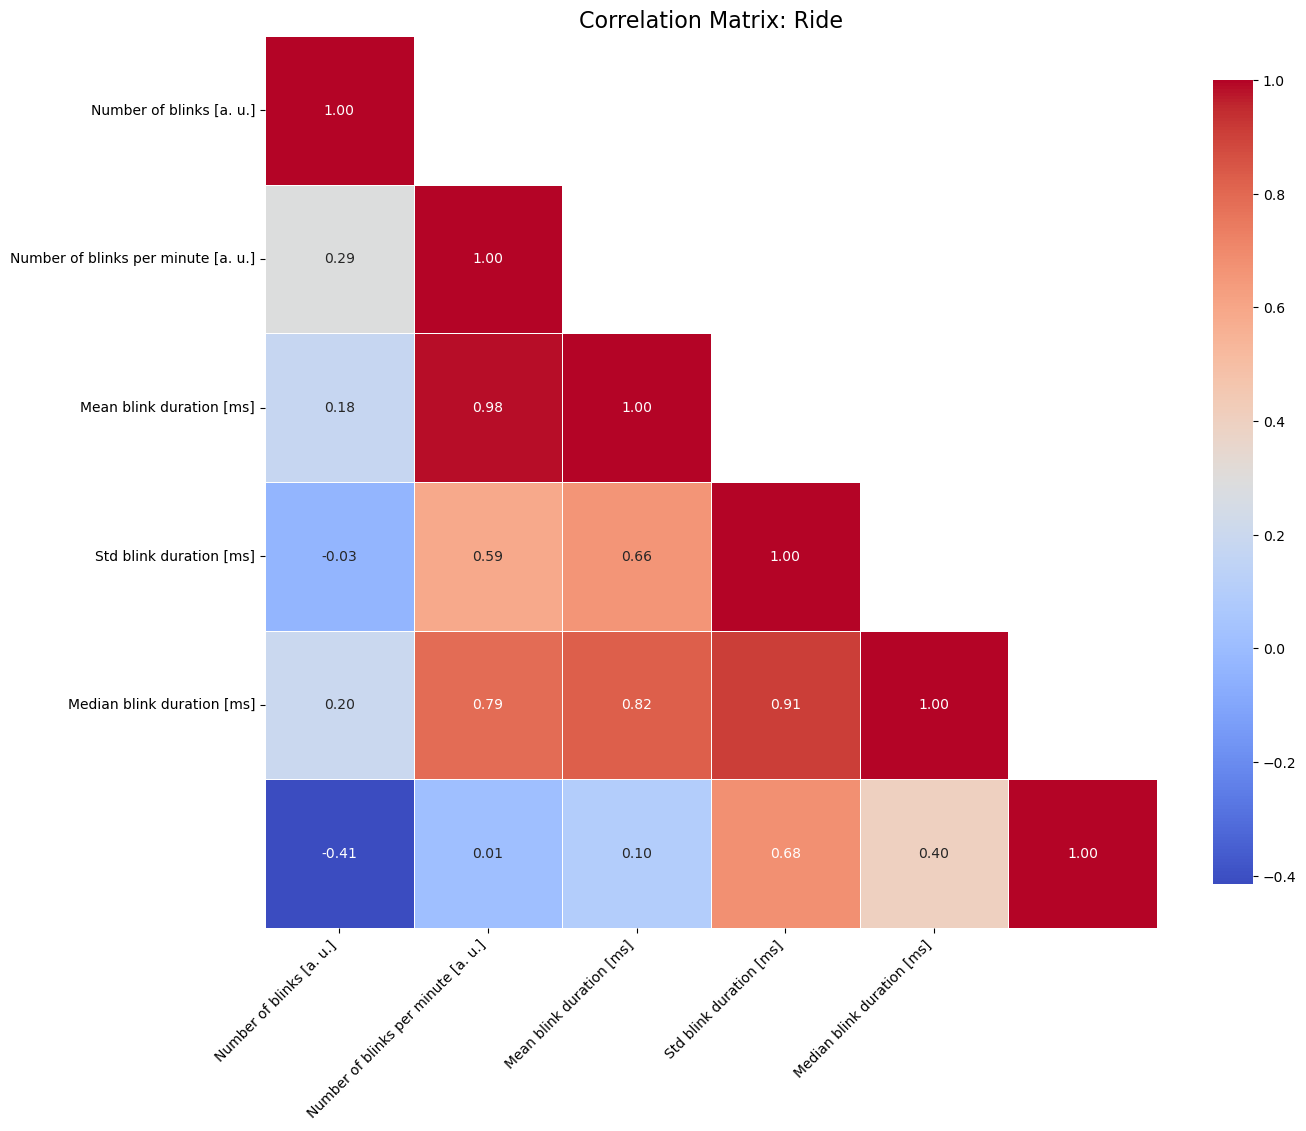

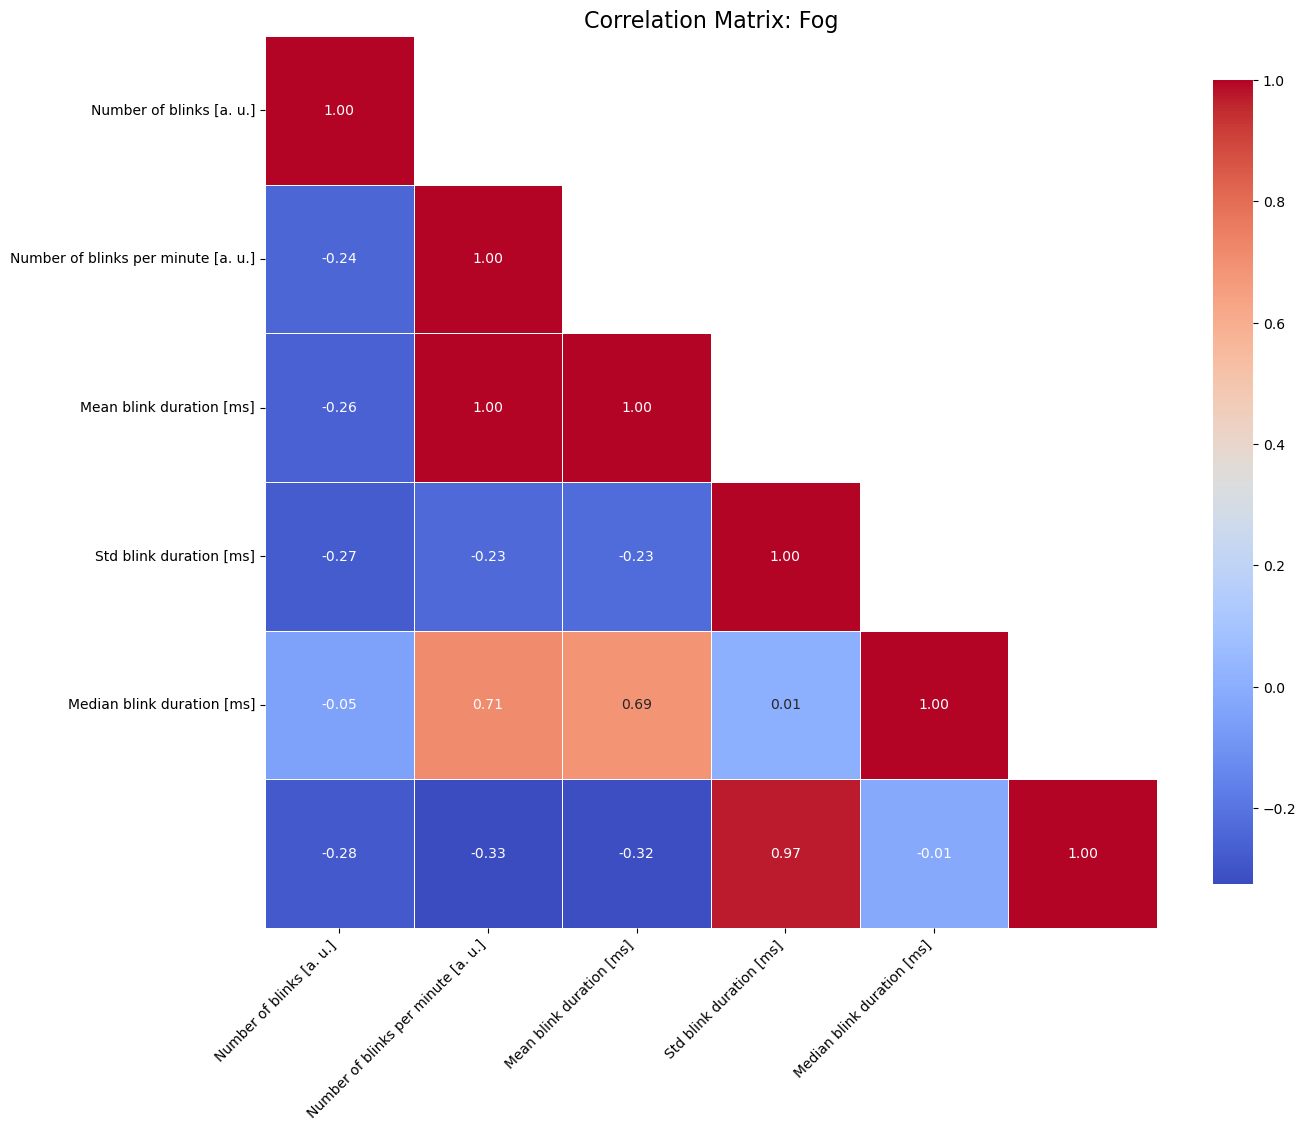

In [8]:
custom_titles = [
    'Number of blinks [a. u.]',
    'Number of blinks per minute [a. u.]',
    'Mean blink duration [ms]',
    'Std blink duration [ms]',
    'Median blink duration [ms]']

def plot_lower_triangle(corr_matrix, title, filename):
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool),k=1)
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        corr_matrix, 
        mask=mask, 
        cmap=cmap, 
        annot=True, 
        fmt=".2f", 
        linewidths=.5,
        square=True, 
        cbar_kws={"shrink": .8}, 
        xticklabels=[label.replace('_', ' ') for label in custom_titles],
        yticklabels=[label.replace('_', ' ') for label in custom_titles]
    )
    plt.title(title, fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# Plot and save
plot_lower_triangle(corr_combined, 'Correlation Matrix: Baseline + Ride Combined', 'Blinks_combined.jpg')
plot_lower_triangle(corr_baseline, 'Correlation Matrix: Baseline', 'Blinks_baseline.jpg')
plot_lower_triangle(corr_ride, 'Correlation Matrix: Ride', 'Blinks_ride.jpg')
plot_lower_triangle(corr_fog, 'Correlation Matrix: Fog', 'Blinks_fog.jpg')